* Minh Trinh
* Math 318, Winter 2026
* January 30, 2026

In [59]:
# Import necessary packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import statsmodels.formula.api as smf
import statsmodels.api as sm
from ISLP.models import (ModelSpec as MS, summarize, poly)

# Multiple Linear Regression

(a) Fit a multiple regression model to predict `Sales` using `Price`, `Urban`, and `US`.

In [60]:
carseats = pd.read_csv('C:/Users/trinh/Desktop/MATH 318-001 Homework/data/Carseats.csv')
carseats

,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
0,9.50,138,73,11,276,120,Bad,42,17,Yes,Yes
1,11.22,111,48,16,260,83,Good,65,10,Yes,Yes
2,10.06,113,35,10,269,80,Medium,59,12,Yes,Yes
3,7.40,117,100,4,466,97,Medium,55,14,Yes,Yes
4,4.15,141,64,3,340,128,Bad,38,13,Yes,No
...,...,...,...,...,...,...,...,...,...,...,...
395,12.57,138,108,17,203,128,Good,33,14,Yes,Yes
396,6.14,139,23,3,37,120,Medium,55,11,No,Yes
397,7.41,162,26,12,368,159,Medium,40,18,Yes,Yes
398,5.94,100,79,7,284,95,Bad,50,12,Yes,Yes


In [61]:
print(carseats['Price'].dtypes)
print(carseats['Urban'].dtypes)
print(carseats['US'].dtypes)

int64
object
object


To perform automatic recoding, `ModelSpec` requires as the `category` type for categorical variables, but Pandas default to the generic `object` type for unknown string data in columns, like `Urban` and  `US`.

Source: [Building design matrices with `ModelSpec`](https://islp.readthedocs.io/en/latest/models/spec.html)

In [62]:
# Recast `Urban` and `US` as `category` type
carseats['Urban'] = carseats['Urban'].astype('category')
carseats['US'] = carseats['US'].astype('category')

In [63]:
# Set `Price`, `Urban`, and `US` as predictor variables
# Call fit_transform to one-hot encode 'Urban' and 'US'
design = MS(['Price', 'Urban', 'US']) 
X = design.fit_transform(carseats)

# Set `Sales` as the response variable
y = carseats['Sales']

# Fit variables to OLS model using `sm.OLS`
model = sm.OLS(y, X)
results = model.fit()

In [64]:
# Summarize results
summarize(results)

,coef,std err,t,P>|t|
intercept,13.0435,0.651,20.036,0.000
Price,-0.0545,0.005,-10.389,0.000
Urban[Yes],-0.0219,0.272,-0.081,0.936
US[Yes],1.2006,0.259,4.635,0.000


In [65]:
# View results summary
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Sales   R-squared:                       0.239
Model:                            OLS   Adj. R-squared:                  0.234
Method:                 Least Squares   F-statistic:                     41.52
Date:                Wed, 04 Feb 2026   Prob (F-statistic):           2.39e-23
Time:                        21:27:08   Log-Likelihood:                -927.66
No. Observations:                 400   AIC:                             1863.
Df Residuals:                     396   BIC:                             1879.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     13.0435      0.651     20.036      0.000      11.764      14.323
Price         -0.0545      0.005    -10.389      0.000      -0.065      -0.044
Urban[Yes]    -0.0219      0.272     -0.081      0.936      -0.556       0.512
US[Yes]        1.2006      0.259      4.635      0.000       0.691       1.710
==============================================================================
Omnibus:                        0.676   Durbin-Watson:                   1.912
Prob(Omnibus):                  0.713   Jarque-Bera (JB):                0.758
Skew:                           0.093   Prob(JB):                        0.684
Kurtosis:                       2.897   Cond. No.                         628.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

# Coefficient Interpretations

(b)  Provide an interpretation of each coefficient in the model. Be careful — some of the variables in the model are qualitative!

Based on the model, `Price` has a coefficient of $-0.0545$, meaning that for every 1 unit increase in price, sales decrease by 0.0545 units. For the qualitative variables, `ModelSpec` transformed `Urban` and `US` into dummy variables, where the switch represents a change from `No` to `Yes`. If the `US[Yes]` switch is on, its coefficient of `1.2006` suggests that sales increase by 1.2006 units for stores within the US compared to those outside the US, holding all other variables constant. If the `Urban[Yes]` switch is on, its coefficient of `0.0219` suggests that sales decrease by 0.0219 units in urban areas compared to rural areas. 

When $Price = 0$ and the store is neither in the US or in an urban area (the baseline), the model predicts average sales of approximately `13.0435` units.

# Model Equation

(c) Write out the model in equation form, being careful to handle
the qualitative variables properly.

The OLS model written in equation form:

$$Sales = \beta_0 + \beta_1(Price) + \beta_2(Urban[Yes]) + \beta_3(US[Yes])$$

* $Sales$: Response variable representing the units sold
* $\beta_0$ (Intercept): The constant, or the baseline average sales when $Price = 0$ and the store is is neither in the US or in an urban area
* $\beta_1$: The change in sales for every one-unit increase in `Price`, holding all other variables constant
* $Price$: Continuous predictor variable
* $\beta_2$: The average difference in sales between urban and non-urban stores, holding all other variables constant
* $Urban[Yes]$: The dummy variable for store location, switching on (1) for urban areas and off (0) for non-urban areas
* $\beta_3$: The average difference in sales between stores located in the US and those located abroad, holding all other variables constant
* $US[Yes]$: The dummy variable for store country, switching on (1) for U.S. and off (0) for non-U.S

The model in equation form based on the results summary:

$$Sales = 13.0435 - 0.0545(Price) - 0.0219(Urban[Yes]) + 1.2006(US[Yes])$$

# Hypothesis Testing

(d) For which of the predictors can you reject the null hypothesis $H_0: \beta_j=0$?

For the `Price` predictor, with a $p-value = 0.000 < \alpha = 0.05$ (the $5\%$ significance level), I can reject the null hypothesis. This suggests the relationship between `Price` and `Sales` is statistically significant.

Similarly, for the `US[Yes]` dummy variable, with a $p-value = 0.000 < \alpha = 0.05$, I can reject the null hypothesis. This suggests the relationship between `US[Yes]` and `Sales` is also statistically significant.

However, for the `Urban[Yes]` dummy variable, its $p-value = 0.936 > \alpha = 0.05$, so I cannot reject the null hypothesis. This suggests the change in the `Sales` response variable for urban stores could have happened by chance; there is not enough evidence to say that a store's urban location affects its sales.

# Fit Smaller Model 

(e) On the basis of your response to the previous question, fit a smaller model that only uses the predictors for which there is evidence of association with the outcome.

In [66]:
# Set `Price` and `US` as predictor variables
# Call fit_transform to one-hot encode 'US'
design_2 = MS(['Price', 'US'])
X_2 = design_2.fit_transform(carseats)

# Set `Sales` as the response variable
y = carseats['Sales']

# Fit variables to OLS model using `sm.OLS`
model_2 = sm.OLS(y, X_2)
results_2 = model_2.fit()

In [67]:
# Summarize results
summarize(results_2)

,coef,std err,t,P>|t|
intercept,13.0308,0.631,20.652,0.0
Price,-0.0545,0.005,-10.416,0.0
US[Yes],1.1996,0.258,4.641,0.0


In [68]:
# View results summary
results_2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Sales   R-squared:                       0.239
Model:                            OLS   Adj. R-squared:                  0.235
Method:                 Least Squares   F-statistic:                     62.43
Date:                Wed, 04 Feb 2026   Prob (F-statistic):           2.66e-24
Time:                        21:27:09   Log-Likelihood:                -927.66
No. Observations:                 400   AIC:                             1861.
Df Residuals:                     397   BIC:                             1873.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     13.0308      0.631     20.652      0.000      11.790      14.271
Price         -0.0545      0.005    -10.416      0.000      -0.065      -0.044
US[Yes]        1.1996      0.258      4.641      0.000       0.692       1.708
==============================================================================
Omnibus:                        0.666   Durbin-Watson:                   1.912
Prob(Omnibus):                  0.717   Jarque-Bera (JB):                0.749
Skew:                           0.092   Prob(JB):                        0.688
Kurtosis:                       2.895   Cond. No.                         607.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

# Model Fit Comparison

(f) How well do the models in (a) and (e) fit the data?

Based on the OLS results, the model in (e) is better for predicting car seat sales. While both OLS models have $R^2 = 0.239$, explaining 23.9% of the variation in `Sales`, the model in (e) maintain this explanatory power with fewer features. The formula for $R^2$: $$R^2 = 1- \frac{RSS}{TSS}$$
* $RSS$: Residual Sum Squares
* $TSS$: Total Sum Squares (TSS)

Based on its formula, $R^2$ displays the total variance in `Sales` that the OLS models capture. While $R^2$ will increase with more variables added (even noisy ones), Adjusted $R^2$ penalize noisy variables. The formula for Adjusted $R^2$:$$\bar{R}^2 = 1 - (1 - R^2) \frac{n - 1}{n - p - 1}$$
* $n$: The total number of observations (sample size)
* $p$: The number of predictors in the model

So, removing the noisy `Urban[Yes]` variable ($p=0.936 > \alpha=0.05$) slightly improved the Adjusted $R^2$ for the model in (e) from 0.234 to 0.235, suggesting that it's more efficient compared to the model in (a).

In addition to the slight jump in Adjusted $R^2$, the more rigorous F-statistic proves that the model in (e) fits the data better. The formula for the F-statistic penalizes complexity by dividing the explained variance by the number of predictors ($p$):$$F = \frac{(TSS - RSS) / d}{RSS / (n - p - 1)}$$

* $(TSS - RSS) / p$: The Mean Square Model, representing the amount of variance explained by every predictor on average
* $RSS / (n - p - 1)$: The Mean Square Error (MSE), representing the average amount of unexplained variance for each remaining degree of freedom

By removing `Urban[Yes]`, $p$ decreases, which caused the overall F-statistic to become much larger, jumping from 41.52 in model (a) to 62.43 in model (e). With a `Prob (F-statistic)` of roughly $2.66e-24$, this shows that model (e) is more statistically significant and a more effective fit for the data.

Note: The F-statistic avoids p-hacking by performing Global Hypothesis Test, which asks if at least one predictor variable is useful.

# Confidence Intervals

(g) Using the model from (e), obtain 95% confidence intervals for the coefficient(s).

In [78]:
conf_intervals = results_2.conf_int(alpha=0.05)
conf_intervals

,0,1
intercept,11.79032,14.271265
Price,-0.06476,-0.044195
US[Yes],0.69152,1.707766


# Outlier and Leverage

(h) Is there evidence of outliers or high leverage observations in the model from (e)?

In [70]:
# Define influence from results
influence = results_2.get_influence()

# Get studentized residuals to check for outliers
studentized_residuals = influence.resid_studentized_internal

# Find outliers where |studentized residual| > 3
outliers = studentized_residuals[np.abs(studentized_residuals) > 3]
print(f'Outliers: {outliers}')

Outliers: []


In [71]:
# Define average leverage threshold
n = len(studentized_residuals)
# Number of predictors: `Price` and `US`
p = 2 

# Formula from ISLR Section 3.3.3: (p + 1) / n
average_leverage = (p + 1) / n
print(f'Average Leverage: {average_leverage}')

# Define leverage (hat values)
hat_values = influence.hat_matrix_diag

# Get the index of observation with the highest leverage
print(f'Index of Observation with Highest Leverage: {np.argmax(influence.hat_matrix_diag)}')

Average Leverage: 0.0075
Index of Observation with Highest Leverage: 42


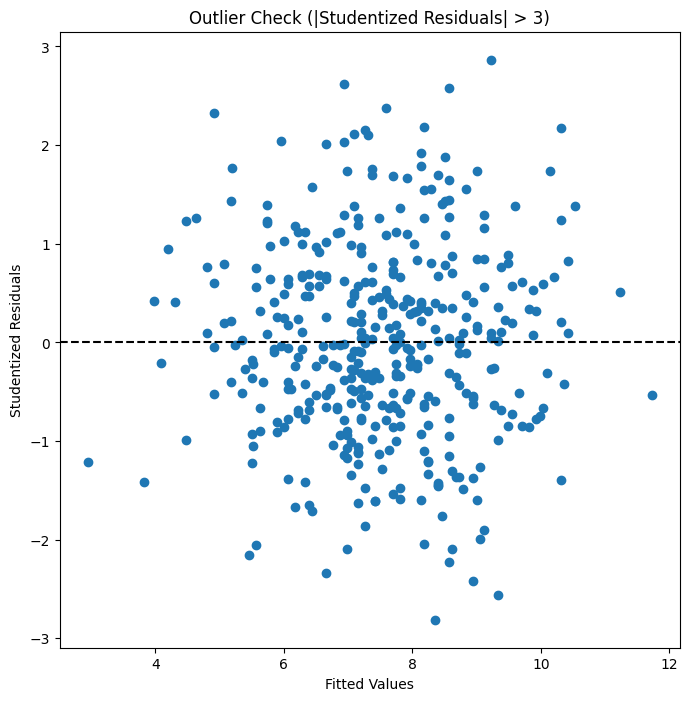

In [72]:
# Plot 1: Outlier Check (|Studentized Residuals| > 3)
ax = plt.subplots(figsize=(8, 8))[1]
ax.scatter(results_2.fittedvalues, studentized_residuals)
ax.axhline(0, c='k', ls='--');
ax.set_xlabel('Fitted Values')
ax.set_ylabel('Studentized Residuals')
ax.set_title('Outlier Check (|Studentized Residuals| > 3)')

plt.show()

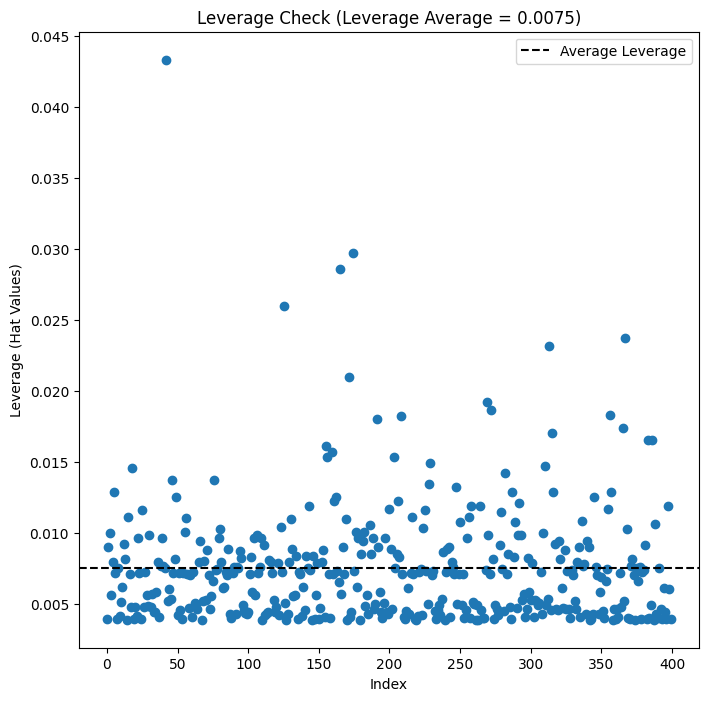

In [76]:
# Plot 2: Leverage Check (Leverage Average = 0.0075)
ax = plt.subplots(figsize=(8, 8))[1]
ax.scatter(np.arange(X_2.shape[0]), hat_values)
ax.axhline(average_leverage, c='k', ls='--', label='Average Leverage')
ax.set_xlabel('Index')
ax.set_ylabel('Leverage (Hat Values)')
ax.set_title(f'Leverage Check (Leverage Average = {average_leverage})')
ax.legend()

plt.show()

Based on the Leverage Check, there are observations that are above the average leverage of $0.0075$, particularly the observation at index 42. However, based on the Outlier Check, there is no evidence of outliers since all studentized residuals are within $|3|$. Checking the observation at index 42:

In [74]:
carseats.iloc[42]

Sales           10.43
CompPrice          77
Income             69
Advertising         0
Population         25
Price              24
ShelveLoc      Medium
Age                50
Education          18
Urban             Yes
US                 No
Name: 42, dtype: object